<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 5 — Maldición de la Dimensionalidad, PCA, K-means y DBSCAN</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Pasamos del aprendizaje supervisado al **aprendizaje no supervisado**. En los challenges anteriores conocías la etiqueta de cada paciente; aquí trabajarás **sin etiquetas**.

El dataset es el **Breast Cancer Wisconsin** (UCI / sklearn, 1995): 569 registros de biopsias de mama con 30 features numéricas calculadas a partir de imágenes digitalizadas de aspirado con aguja fina (FNA). Cada feature describe propiedades geométricas y texturales del núcleo celular (radio, textura, perímetro, área, suavidad, compacidad…).

**Pregunta clínica:** ¿Puede un algoritmo no supervisado encontrar subgrupos de tumores que se correspondan con el diagnóstico real (maligno / benigno) sin usar las etiquetas en ningún momento del entrenamiento? Al final del challenge revelaremos las etiquetas para evaluar qué tan bien los clusters recuperan la estructura clínica.

---
> **Fuente:** Wolberg, W. H. et al. (1995). *Breast Cancer Wisconsin (Diagnostic) Dataset*. UCI ML Repository.  
> Disponible directamente en `sklearn.datasets.load_breast_cancer()` — no requiere descarga.

### Estructura de carpetas
```
Clase6_Challenge5/
└── Challenge5_ApellidoNombre.ipynb    ← no se necesita CSV externo
```

---
## Ejercicio 1 — Diseño previo al código

### 1.1 — Maldición de la dimensionalidad

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

**1.** En un hipercubo d-dimensional $[0,1]^d$ con datos uniformes, para capturar una fracción $f$ de los datos con un hipercubo de vecindad de lado $l$, demuestra que:

$$l(f, d) = f^{1/d}$$

Calcula $l(0.01, d)$ para $d = 1, 5, 10, 30$ y completa la tabla:

| $d$ | $l(0.01,\, d)$ | Interpretación |
|---|---|---|
| 1 | 0.01 | En 1D, solamente con un lado de 0.01 se obtiene el 1% del eje. |
| 5 | 0.398 | En 5D, en cambio, se necesita un aprox de 40% de cada lado del cubo para obtener solamente el 1% de los datos.|
| 10 | 0.631 | En 10D aumenta mucho más, para un 1% se necesita un 63% de cada lado. |
| 30 | 0.858 | En 30D se demuestra que se necesita casi el 86% de cada eje para solo obtener el 1% de los datos.|

**📝 Tu respuesta: ** Podemos visualizar que a medida que aumentan las dimensiones, se necesita abarcar más porcentaje de cada eje, de cada dimensión, para abarcar un porcentaje pequeño de lo que es el volumen total del hipercubo.

---

**2.** ¿Por qué la maldición de la dimensionalidad afecta a kNN pero es menos problemática para PCA?

**📝 Tu respuesta:** Afecta más a kNN por su formulación al depender del cálculo de distancias entre muestras. Si las dimensiones aumentan en gran proporción, la dispersión de los datos aumenta, por lo que se pierde esa relación que busca el kNN al medir sus distancias, ya que estas tenderán a parecerse y se perderá su valor. En cambio, PCA se basa mas en un algoritmo de matrices y vectores determinados por la varianza para hallar direcciones, entonces este se basa en lo que es la covarianza y no en sus distancias, por lo que también ignora aquellas dimensiones que no influyen en el dataset, reduciendo la complejidad a solamente los componentes principales.

---

**3.** ¿Por qué es útil reducir con PCA antes de aplicar K-means o DBSCAN?

**📝 Tu respuesta:** Por lo antes mencionado, el PCA actuaría como un filtro para grandes dimensiones, ya que las simplificaría en un grupo reducido de componentes principales. Entonces, esto facilitaría a K-means o al DBSCAN al momento de encontrar dataset menos complejas y de menor dimensionalidad, permitiendo encontrar agrupamientos más claros.

---

**4.** Observa la gráfica de contraste de distancias que se generará en el Paso 3.1.  
¿Qué ocurre con la diferencia relativa entre la distancia mínima y máxima cuando aumenta la dimensionalidad?

**📝 Tu respuesta:** Se puede ver que cuando aumenta la dimensionalidad, la diferencia relativa entre la distancia máxima y mínima disminuye en gran medida, a tal punto que desde las 10 dimensiones alcanza valores tan pequeños que ya no puede decrecer más. Esto indica que a mayor dimensionalidad, la diferencia relativa se reduce, indicando que las distancias entre puntos se vuelven más similares, por lo que se pierde el contraste entre datos vecinos cercanos y lejanos.

---

**5.** Si K-means y DBSCAN dependen de distancias, ¿por qué la pérdida de contraste de distancias puede afectar la calidad del clustering?

**📝 Tu respuesta:** Por lo dicho anteriormente, si las distancias relativas son casi iguales entre datos lejanos y cercanos, se pierde la capacidad de distinguir patrones de cercanía entre los datos. Esto hace que tanto para K-means y DBSCAN sea más complejo identificar patrones y que sus resultados sean menos confiables.


### 1.2 — PCA: matemática

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

Sea $\tilde{X} \in \mathbb{R}^{N \times d}$ el dataset centrado y $\Sigma = \frac{1}{N}\tilde{X}^T\tilde{X}$ la matriz de covarianza muestral.

**1.** El primer componente principal $\mathbf{v}_1$ maximiza la varianza proyectada:

$$\mathbf{v}_1 = \arg\max_{\|\mathbf{v}\|=1} \mathbf{v}^T \Sigma \mathbf{v}$$

Usando multiplicadores de Lagrange, demuestra que $\mathbf{v}_1$ debe satisfacer: $\Sigma\mathbf{v}_1 = \lambda_1 \mathbf{v}_1$.

¿Qué significa esto en términos de álgebra lineal?

**📝 Tu respuesta:** Para el PCA, el primer componente principal $\mathbf{v}_1$ es el que dicta la dirección principal que es aquella donde los datos tienen mayor varianza. Entonces, esa fórmula significa que $\mathbf{v}_1$ es el vector propio de la matriz de covarianza. $\lambda$ es el valor propio de este vector, un factor que indica la importancia de la dirección del $\mathbf{v}_1$, por ende, su $\lambda$ es aquel de mayor magnitud.

---

**2.** Completa la fórmula de varianza acumulada explicada por los primeros $r$ componentes:

$$\text{VE}(r) = \frac{\sum_{k=1}^{r} \, \lambda_k}{\sum_{k=1}^{d} \, \lambda_k}$$

---

**3.** ¿Sobre qué conjunto se debe ajustar el PCA (fit) y por qué? ¿Cuál es la relación con el data leakage?

**📝 Tu respuesta:** Al ajustar el PCA, este aprende de los datos, calculando la media y la matriz de covarianza. Entonces, solo debería usarse en el conjunto de entrenamiento, porque si se usa en todos los datos, incluyendo el de test, ocurrirá data leakage. <br>Si se ajusta con los datos del test, la media y la covarianza poseeran valores influenciados por este set y así los resultados no serán realistas, ya que el modelo habría usado información que, en la teoría, no debería conocer.

### 1.3 — K-means vs DBSCAN y pipeline

Completa el siguiente diagrama de pipeline:

```
load_breast_cancer()  →  569 muestras, 30 features
        │
        ▼
[ Paso A ] Estandarización de la matriz de datos
        │
        ▼
[ Paso B ] PCA: Reducción de la dimensionalidad  → elegir r* por mayor varianza
        │
        ▼
        ├──── K-means: Clustering en base a centroides → K* elegido por el Método del Codo
        │
        └──── DBSCAN:  Clustering en base a densidad  → ε* elegido por el k-distance graph, min_samples = criterio o mediante pruebas
        │
        ▼
[ Paso C ] Comparación: Métricas y visualización de clusters
```

Completa también la siguiente tabla comparativa:

| | K-means | DBSCAN |
|---|---|---|
| Forma de clusters | Esférica | Arbitraria |
| Manejo de outliers | Sensible | Menos sensible |
| Parámetros clave | K | ε |
| Función objetivo | Minimizar la varianza intra-cluster | Agrupar por densidad |

**📝 Tu respuesta:** completa los blancos arriba.

---
## Ejercicio 2 — Setup y carga de datos

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 2.1 — Librerías

In [1]:
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'
UPCH_PURPLE = '#6A1B9A'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# TODO 1: importa PCA desde sklearn.decomposition
from sklearn.decomposition import PCA

# TODO 2: importa KMeans y DBSCAN desde sklearn.cluster
from sklearn.cluster import KMeans, DBSCAN

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              adjusted_rand_score, davies_bouldin_score)

plt.rcParams['figure.dpi'] = 120
print('Setup completo ✓')

Setup completo ✓


### Paso 2.2 — Carga del dataset

In [2]:
# ── Carga del dataset ──────────────────────────────────────────
data       = load_breast_cancer()
X          = data.data
feat_names = data.feature_names

print(f'Shape: {X.shape}')
print(f'Features ({len(feat_names)}): {list(feat_names[:5])} ...')
print()
print('Trabajaremos como problema NO supervisado.')
print('Las etiquetas reales se revelarán recién en el Ejercicio 6 para evaluar el clustering.')

Shape: (569, 30)
Features (30): [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')] ...

Trabajaremos como problema NO supervisado.
Las etiquetas reales se revelarán recién en el Ejercicio 6 para evaluar el clustering.


### Paso 2.3 — EDA inicial: mapa de correlación

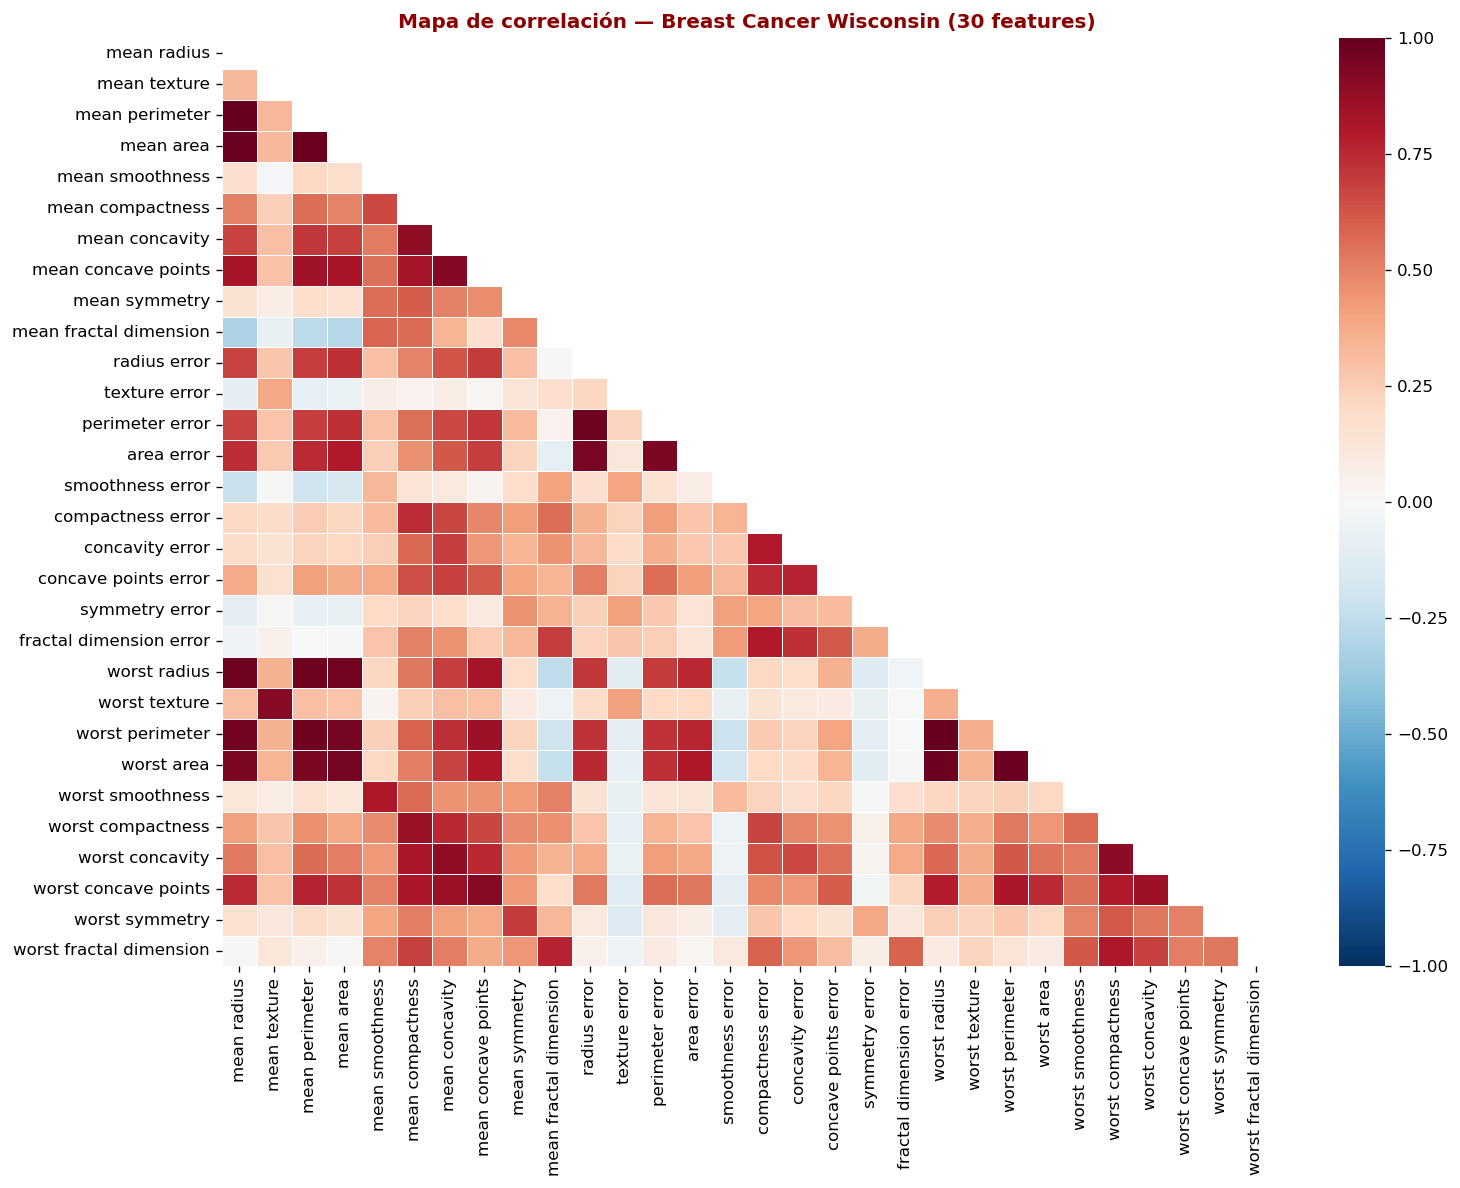

→ ¿Qué observas? ¿Por qué hay tantas correlaciones altas?
Se observan muchas correlaciones altas entre variables porque varias features describen propiedades geométricas relacionadas del mismo núcleo celular. 
Por ejemplo, radio, perímetro y área están matemáticamente y biológicamente conectados, si el tamaño del núcleo aumenta, las otras variables también lo hacen. 
Además, el dataset contiene medidas derivadas similares (mean, worst, standard error), lo que introduce redundancia y multicolinealidad.


In [5]:
# ── Mapa de correlación (features originales) ──────────────────
# Este código está completo — ejecútalo y analiza el resultado

fig, ax = plt.subplots(figsize=(13, 10))
corr = pd.DataFrame(X, columns=feat_names).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title('Mapa de correlación — Breast Cancer Wisconsin (30 features)',
             fontsize=12, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué observas? ¿Por qué hay tantas correlaciones altas?')
print('Se observan muchas correlaciones altas entre variables porque varias features describen propiedades geométricas relacionadas del mismo núcleo celular. \n'
'Por ejemplo, radio, perímetro y área están matemáticamente y biológicamente conectados, si el tamaño del núcleo aumenta, las otras variables también lo hacen. \n'
'Además, el dataset contiene medidas derivadas similares (mean, worst, standard error), lo que introduce redundancia y multicolinealidad.')

---
# PARTE 1 — Maldición de la Dimensionalidad y PCA
## Ejercicio 3 — Maldición de la dimensionalidad y PCA

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 3.1 — Visualización de la maldición de la dimensionalidad

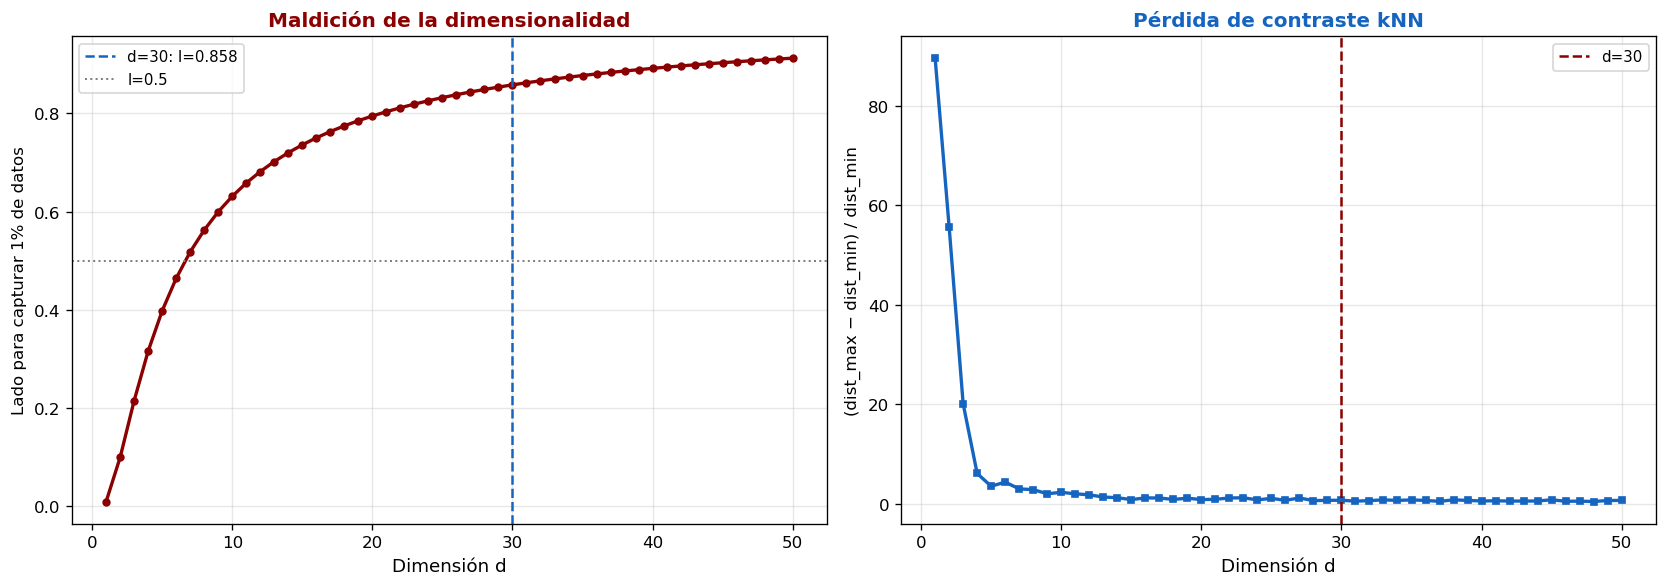

In [6]:
# ── Maldición de la dimensionalidad ────────────────────────────
f    = 0.01
dims = list(range(1, 51))

# TODO 3: calcula la longitud de lado necesaria para capturar
#          fracción f de datos en cada dimensión d
#          fórmula: l(f, d) = f^(1/d)
edge_lengths = [f**(1/d) for d in dims]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(dims, edge_lengths, 'o-', color=UPCH_RED, lw=2, markersize=4)
axes[0].axvline(30, color=UPCH_BLUE, ls='--', lw=1.5,
                label=f'd=30: l={0.01**(1/30):.3f}')
axes[0].axhline(0.5, color='gray', ls=':', lw=1.2, label='l=0.5')
axes[0].set_xlabel('Dimensión d', fontsize=11)
axes[0].set_ylabel(f'Lado para capturar {100*f:.0f}% de datos', fontsize=10)
axes[0].set_title('Maldición de la dimensionalidad', fontsize=12,
                   fontweight='bold', color=UPCH_RED)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# TODO 4: calcula el contraste de distancias kNN para cada dimensión
#          (la segunda gráfica ya está armada — solo necesitas el vector contrast)
np.random.seed(42)
n_pts = 200
contrast = []
for d in range(1, 51):
    pts = np.random.uniform(0, 1, (n_pts, d))
    ref = pts[0:1, :]
    dists = np.sqrt(((pts[1:] - ref)**2).sum(axis=1))
    # TODO 4: calcula c = (dists.max() - dists.min()) / dists.min()
    c = (dists.max() - dists.min()) / dists.min()
    contrast.append(c)

axes[1].plot(range(1, 51), contrast, 's-', color=UPCH_BLUE, lw=2, markersize=4)
axes[1].axvline(30, color=UPCH_RED, ls='--', lw=1.5, label='d=30')
axes[1].set_xlabel('Dimensión d', fontsize=11)
axes[1].set_ylabel('(dist_max − dist_min) / dist_min', fontsize=10)
axes[1].set_title('Pérdida de contraste kNN', fontsize=12,
                   fontweight='bold', color=UPCH_BLUE)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curse_dimensionality.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 3.2 — PCA: varianza acumulada

Componentes para ≥90% varianza: 7
Componentes para ≥95% varianza: 10
Varianza explicada por PC1+PC2: 63.2%


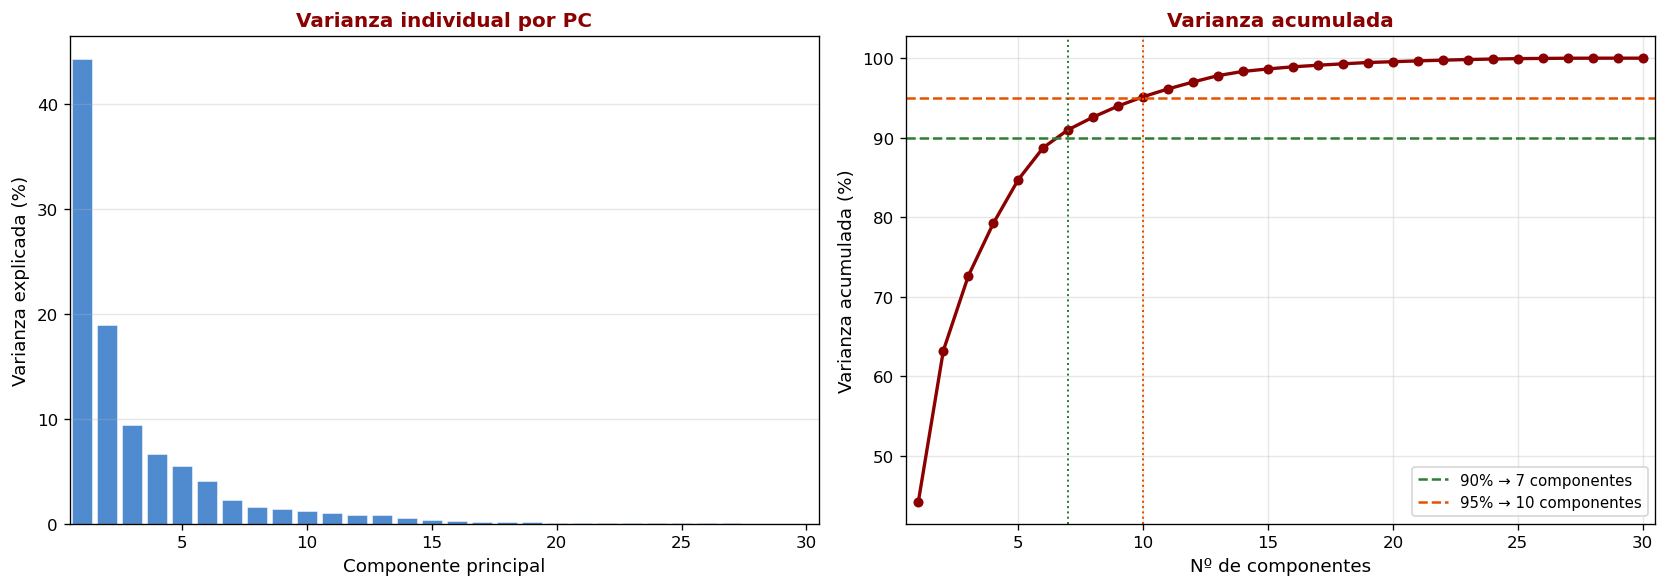

In [7]:
# ── PCA: varianza acumulada ─────────────────────────────────────
# TODO 5: estandariza X con StandardScaler
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

# TODO 6: crea un PCA completo (todas las componentes) y ajústalo
pca_full = PCA()
pca_full.fit(X_sc)

var_ratio = pca_full.explained_variance_ratio_
var_acum  = np.cumsum(var_ratio)

# TODO 7: encuentra el número de componentes para ≥90% y ≥95% varianza
n_90 = np.argmax(var_acum >= 0.90) + 1
n_95 = np.argmax(var_acum >= 0.95) + 1
print(f'Componentes para ≥90% varianza: {n_90}')
print(f'Componentes para ≥95% varianza: {n_95}')
print(f'Varianza explicada por PC1+PC2: {var_acum[1]:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(var_ratio)+1), var_ratio*100,
            color=UPCH_BLUE, alpha=0.75, edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Componente principal', fontsize=11)
axes[0].set_ylabel('Varianza explicada (%)', fontsize=11)
axes[0].set_title('Varianza individual por PC', fontsize=12,
                   fontweight='bold', color=UPCH_RED)
axes[0].set_xlim(0.5, 30.5)
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].plot(range(1, len(var_acum)+1), var_acum*100,
             'o-', color=UPCH_RED, lw=2, markersize=5)
axes[1].axhline(90, color=UPCH_GREEN,  ls='--', lw=1.5,
                label=f'90% → {n_90} componentes')
axes[1].axhline(95, color=UPCH_ORANGE, ls='--', lw=1.5,
                label=f'95% → {n_95} componentes')
axes[1].axvline(n_90, color=UPCH_GREEN,  ls=':', lw=1.2)
axes[1].axvline(n_95, color=UPCH_ORANGE, ls=':', lw=1.2)
axes[1].set_xlabel('Nº de componentes', fontsize=11)
axes[1].set_ylabel('Varianza acumulada (%)', fontsize=11)
axes[1].set_title('Varianza acumulada', fontsize=12,
                   fontweight='bold', color=UPCH_RED)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0.5, 30.5)
plt.tight_layout()
plt.savefig('pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 3.3 — Proyección 2D y espacio reducido

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

Espacio reducido para clustering: (569, 7)


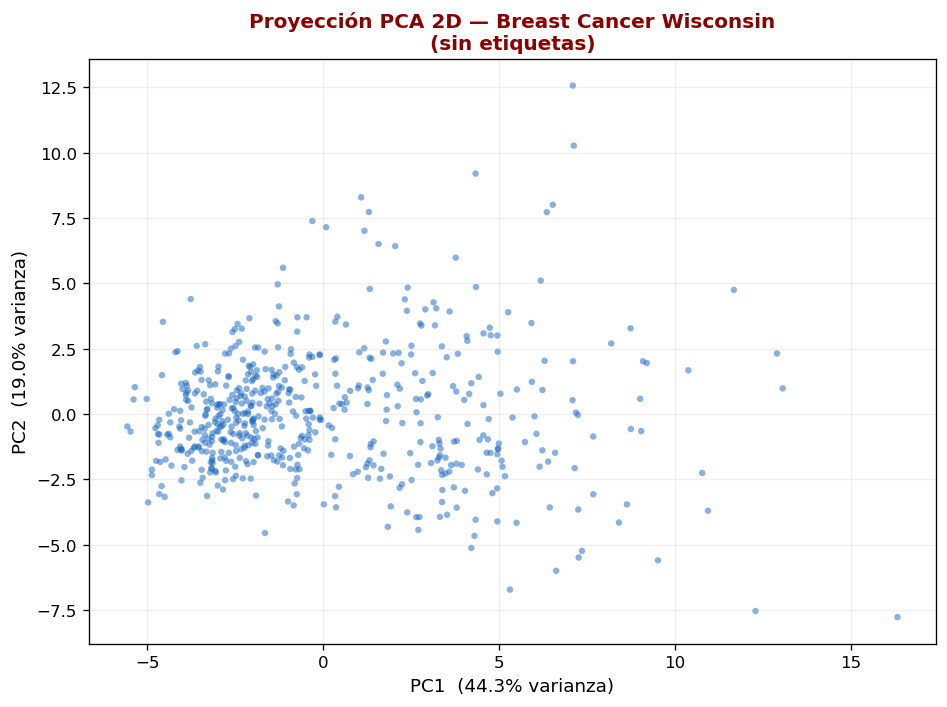

→ ¿Intuyes alguna estructura de grupos en la proyección 2D?
Sí, se intuyen dos grupos principales. Por un lado, existe un grupo denso y compacto a la izquierda, lo que sugiere baja variabilidad. 
Por otro lado, existe un grupo disperso a la derecha, lo que indica alta variabilidad.


In [9]:
# ── PCA: proyección 2D y espacio reducido ──────────────────────
# TODO 8: crea PCA con 2 componentes y proyecta X_sc → Z_2d
pca_2d = PCA(n_components=2)
Z_2d   = pca_2d.fit_transform(X_sc)

# TODO 9: crea PCA con n_90 componentes y proyecta X_sc → Z_pca
#          (este es el espacio que usaremos para clustering)
pca_r = PCA(n_components=n_90)
Z_pca = pca_r.fit_transform(X_sc)
print(f'Espacio reducido para clustering: {Z_pca.shape}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Z_2d[:, 0], Z_2d[:, 1],
           alpha=0.5, s=15, color=UPCH_BLUE, edgecolors='none')
ax.set_xlabel(f'PC1  ({var_ratio[0]:.1%} varianza)', fontsize=11)
ax.set_ylabel(f'PC2  ({var_ratio[1]:.1%} varianza)', fontsize=11)
ax.set_title('Proyección PCA 2D — Breast Cancer Wisconsin\n(sin etiquetas)',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('pca_2d_sin_etiquetas.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Intuyes alguna estructura de grupos en la proyección 2D?')
print('Sí, se intuyen dos grupos principales. Por un lado, existe un grupo denso y compacto a la izquierda, lo que sugiere baja variabilidad. \n'
'Por otro lado, existe un grupo disperso a la derecha, lo que indica alta variabilidad.')

### Paso 3.4 — Interpretación

**📝 Tu respuesta (edita esta celda):**

**1. ¿Qué porcentaje de varianza captura PC1? ¿Qué tipo de información podría estar codificando en este dataset clínico?**
El porcentaje es 44.3% y estaría codificando los datos con más variabilidad, entonces puede ser el tamaño, área o el perímetro del tumor.

**2. ¿Por qué se aplica StandardScaler ANTES de PCA?**
Porque las variables tiene diferentes unidades y escalas, si no se estandarizan se generará un desequilibrio entre aquellos valores muy grandes y los pequeños afectando a la varianza, esto a su vez afectaría a los componentes principales.

**3. ¿Sobre qué conjunto se debe hacer fit() del PCA si se dividiera en train/test? ¿Por qué?**
Sobre el train set, porque el PCA no debe aprender ningún parámetro del test set para que no exista data leakage, mantenga la generalización.

**4. ¿Cuánta varianza explican PC1 + PC2? ¿Crees que 2 componentes son suficientes para análisis cuantitativo o solo para visualización?**
La varianza total es de 63.3%. Dos componentes son útiles para la visualiación, pero se necesitan más para realizar un análisis cuantitativo correcto.

**5. ¿Cuántas componentes se necesitan para explicar al menos 90% y 95% de la varianza? ¿Qué decisión tomarías para clustering?**
Según lo hallado en el 3.2 se necesita 7 y 10 componentes para hallar al menos 90% y 95% de la varianza, respectivamente. Por ello, para conservar más información del dataset en el clustering, usaría más de 7 componentes.


---
# PARTE 2 — K-means Clustering
## Ejercicio 4 — K-means: selección de K y análisis

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 4.1 — Método del codo y Silhouette score

K=2  inertia=   10062.4  silhouette=0.3710
K=3  inertia=    8534.9  silhouette=0.3376
K=4  inertia=    7744.6  silhouette=0.3118
K=5  inertia=    7048.6  silhouette=0.1913
K=6  inertia=    6477.0  silhouette=0.1887
K=7  inertia=    6060.0  silhouette=0.1832
K=8  inertia=    5742.3  silhouette=0.1733
K=9  inertia=    5419.8  silhouette=0.1792
K=10  inertia=    5182.9  silhouette=0.1650


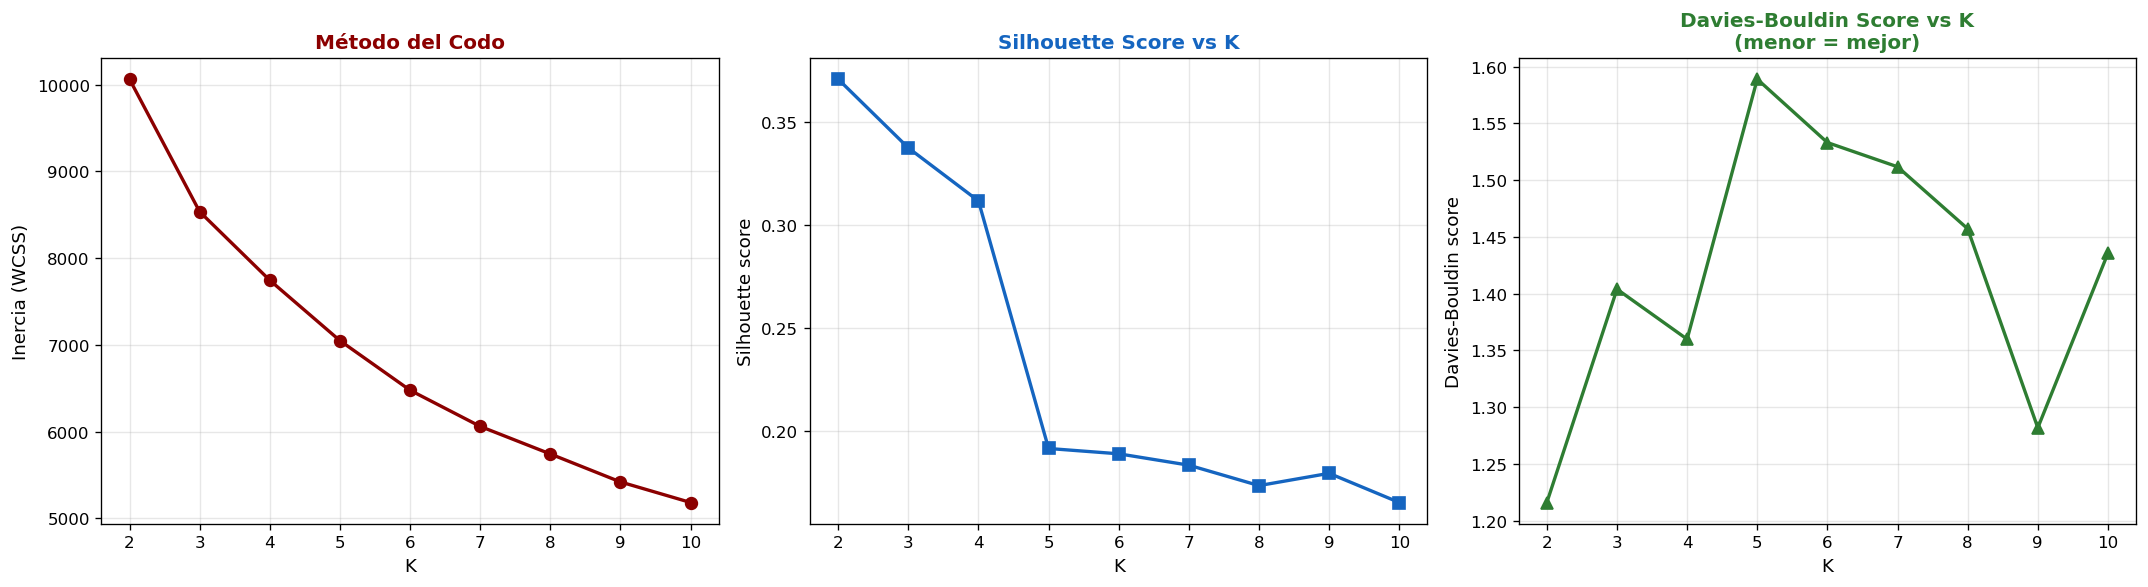

K óptimo: 2  (silhouette=0.3710)


In [10]:
# ── Método del codo (Elbow) + Silhouette ───────────────────────
K_range    = range(2, 11)
inertias   = []
sil_scores = []
db_scores  = []

for k in K_range:
    # TODO 10: crea KMeans con n_clusters=k, random_state=42, n_init=10
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Z_pca)

    # TODO 11: agrega inercia y silhouette score a las listas
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Z_pca, labels))
    db_scores.append(davies_bouldin_score(Z_pca, labels))
    print(f'K={k}  inertia={inertias[-1]:>10.1f}  silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(list(K_range), inertias, 'o-', color=UPCH_RED, lw=2, markersize=7)
axes[0].set_xlabel('K', fontsize=11)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=11)
axes[0].set_title('Método del Codo', fontsize=12, fontweight='bold', color=UPCH_RED)
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_scores, 's-', color=UPCH_BLUE, lw=2, markersize=7)
axes[1].set_xlabel('K', fontsize=11)
axes[1].set_ylabel('Silhouette score', fontsize=11)
axes[1].set_title('Silhouette Score vs K', fontsize=12, fontweight='bold', color=UPCH_BLUE)
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin: valores más BAJOS indican mejor separación
axes[2].plot(list(K_range), db_scores, '^-', color=UPCH_GREEN, lw=2, markersize=7)
axes[2].set_xlabel('K', fontsize=11)
axes[2].set_ylabel('Davies-Bouldin score', fontsize=11)
axes[2].set_title('Davies-Bouldin Score vs K\n(menor = mejor)', fontsize=12, fontweight='bold', color=UPCH_GREEN)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()

# TODO 12: elige el K óptimo según silhouette score máximo
best_k = K_range[np.argmax(sil_scores)]
print(f'K óptimo: {best_k}  (silhouette={max(sil_scores):.4f})')

### Paso 4.2 — Diagrama de Silhouette para K óptimo

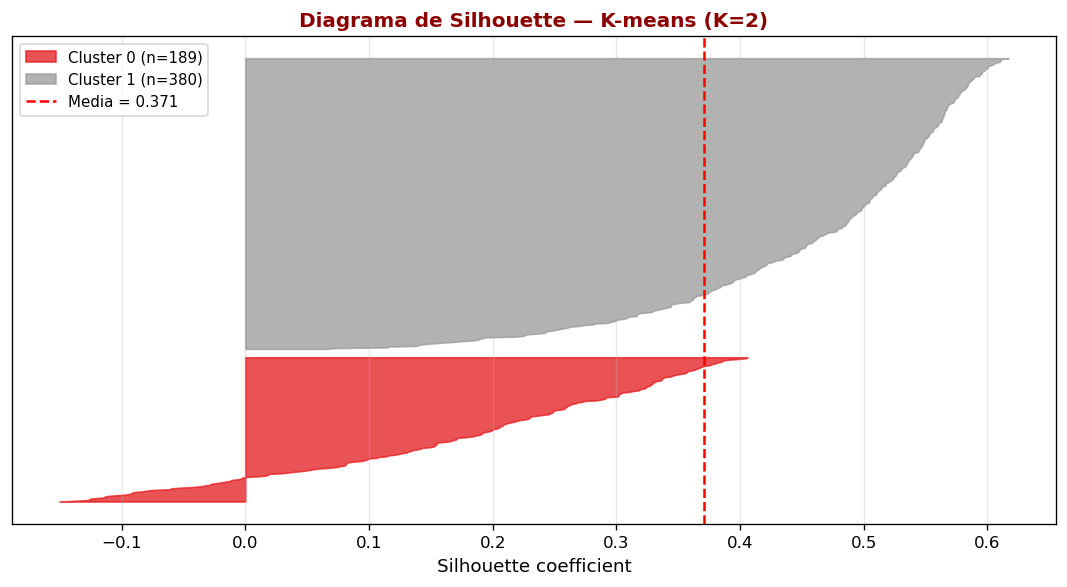

In [11]:
# ── Diagrama de Silhouette para K óptimo ───────────────────────
# TODO 13: entrena KMeans final con best_k
km_best    = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_km  = km_best.fit_predict(Z_pca)

sil_vals = silhouette_samples(Z_pca, labels_km)
sil_avg  = sil_vals.mean()

fig, ax = plt.subplots(figsize=(9, 5))
y_lower  = 10
colors_sil = cm.Set1(np.linspace(0, 0.9, best_k))

for k in range(best_k):
    sil_k  = np.sort(sil_vals[labels_km == k])
    size_k = sil_k.shape[0]
    y_upper = y_lower + size_k
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                     alpha=0.75, color=colors_sil[k],
                     label=f'Cluster {k} (n={size_k})')
    y_lower = y_upper + 10

ax.axvline(sil_avg, color='red', ls='--', lw=1.5,
           label=f'Media = {sil_avg:.3f}')
ax.set_xlabel('Silhouette coefficient', fontsize=11)
ax.set_title(f'Diagrama de Silhouette — K-means (K={best_k})',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9)
ax.set_yticks([])
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 4.3 — Visualización de clusters en espacio PCA

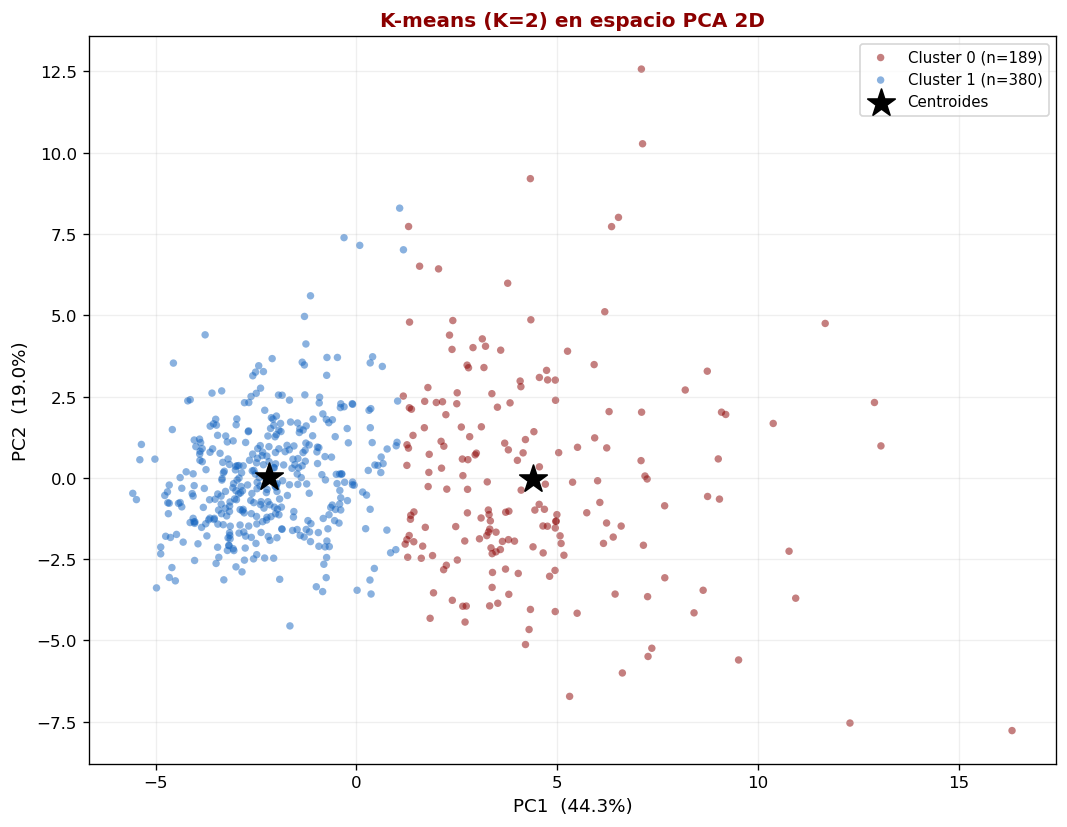

In [12]:
# ── K-means: visualización en espacio PCA 2D ───────────────────
# km_best fue entrenado directamente sobre Z_pca (PC1...PC_r).
# Por tanto, sus centroides YA están en espacio PCA reducido.
# Para graficarlos en PC1 vs PC2 basta tomar sus dos primeras coordenadas.
# Se usa Z_2d (= las mismas PC1 y PC2) para que todos los plots del challenge
# compartan la misma variable de visualización y no haya inconsistencias.
centroids_2d = km_best.cluster_centers_[:, :2]

fig, ax = plt.subplots(figsize=(9, 7))
colors_km = [UPCH_RED, UPCH_BLUE, UPCH_GREEN, UPCH_ORANGE, UPCH_PURPLE]

for k in range(best_k):
    mask = labels_km == k
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               alpha=0.5, s=20, color=colors_km[k % len(colors_km)],
               label=f'Cluster {k} (n={mask.sum()})', edgecolors='none')

ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='*', s=300, zorder=5, label='Centroides')

ax.set_xlabel(f'PC1  ({var_ratio[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2  ({var_ratio[1]:.1%})', fontsize=11)
ax.set_title(f'K-means (K={best_k}) en espacio PCA 2D',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('kmeans_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 4.4 — Interpretación

**📝 Tu respuesta (edita esta celda):**

**1. ¿El método del codo da un K claro? ¿Hay coherencia entre el codo y el peak de silhouette?**
En esta ocasión no se ve un K claro. Según la teoría, en cierto punto, el codo, la curva no debería bajar drásticamente o se puede decir que se debería estabilizar. Sin embargo, en esta gráfica la inercia sigue disminuyendo, por lo que no se puede diferenciar la ubicación del codo. Además, no hay coherencia, porque el peak de silhouette es en k = 2, en cambio en ese valor la gráfica del codo sigue en decaimiento.

**2. ¿Qué implica un silhouette score negativo para alguna muestra?**
Un score negativo indica que una muestra estaría mal asignada, ya que está más cerca del otro cluster que del cluster asignado.

**3. ¿Por qué se visualiza en el espacio PCA 2D si el clustering se hizo en el espacio PCA de n_90 componentes?**
Es imposible visualizar todas las dimensiones en un gráfico, por ello solamente se visualiza en 2 para representar los clústeres de los componentes de mayor varianza de forma sencilla, es más un apoyo visual.

**4. Si eliges un K demasiado pequeño, ¿qué problema aparece? ¿Y si eliges un K demasiado grande?**
Si se elige un K pequeño existe la posibilidad de juntar dos grupos que son diferentes; en cambio, con un K grande puede surgir que clusters bien formados se separen de forma artificial, dando resultados menos interpretables.

**5. En un problema biomédico real, ¿usarías solo el método del codo para elegir K? Justifica tu respuesta.**
No, porque como se puede observar en este caso, puede haber ocasiones donde no pueda distinguir el K necesario. Entonces no solo usaría el método del codo en un problema real, también usaría el silhouette score o el Davies-Bouldin score para asegurar que los grupos encontrados se puedan interpretar mejor.

---
# PARTE 3 — DBSCAN
## Ejercicio 5 — DBSCAN: selección de parámetros y análisis

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 5.1 — k-distance graph para selección de ε

min_samples = 8  (heurística: max(5, d+1) con d=7)


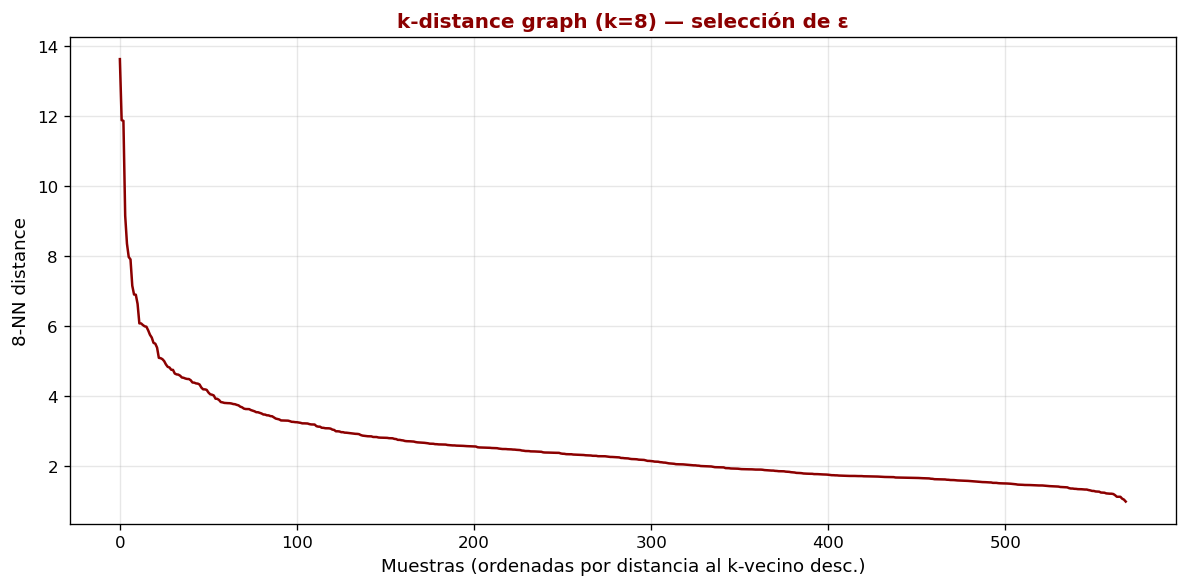

→ Identifica el codo de la curva — ese valor es tu ε óptimo.


In [13]:
# ── k-distance graph para selección de ε ────────────────────────
# Heurística: Ester et al. recomiendan ≥ d+1; se usa max(5, n_90+1)
# para evitar que DBSCAN sea excesivamente restrictivo con d pequeño.
MIN_SAMPLES = max(5, n_90 + 1)
print(f'min_samples = {MIN_SAMPLES}  (heurística: max(5, d+1) con d={n_90})')

nbrs   = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Z_pca)
dists, _ = nbrs.kneighbors(Z_pca)

# TODO 14: extrae la distancia al k-ésimo vecino de cada punto
#           y ordénala de mayor a menor
k_dists = np.sort(dists[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dists, color=UPCH_RED, lw=1.5)
ax.set_xlabel('Muestras (ordenadas por distancia al k-vecino desc.)', fontsize=11)
ax.set_ylabel(f'{MIN_SAMPLES}-NN distance', fontsize=11)
ax.set_title(f'k-distance graph (k={MIN_SAMPLES}) — selección de ε',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Identifica el codo de la curva — ese valor es tu ε óptimo.')

### Paso 5.2 — DBSCAN

In [14]:
# ── DBSCAN ──────────────────────────────────────────────────────
# Detecta el codo del k-distance graph (punto de máxima curvatura).
# El percentil-10 no siempre corresponde al codo visual — este método
# es más robusto. Revisa la gráfica del Paso 5.1 y ajusta si es necesario.
from numpy.linalg import norm as _norm
def _find_elbow(y):
    x = np.arange(len(y), dtype=float)
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    d = p2 - p1; d = d / _norm(d)
    perp = np.array([abs(np.cross(d, np.array([x[i], y[i]]) - p1))
                     for i in range(len(y))])
    return int(np.argmax(perp))

# TODO 15a: el codo ya se detecta automáticamente abajo;
#            revisa la gráfica anterior y ajusta EPS si no coincide visualmente
elbow_idx = _find_elbow(k_dists)
EPS = float(k_dists[elbow_idx])
print(f'ε detectado: {EPS:.4f}  (ajusta si no coincide con el codo visual)')

# TODO 15: crea y ajusta DBSCAN con eps=EPS, min_samples=MIN_SAMPLES
db       = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels_db = db.fit_predict(Z_pca)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise       = (labels_db == -1).sum()
print(f'Clusters encontrados: {n_clusters_db}')
print(f'Puntos de ruido: {n_noise} ({100*n_noise/len(labels_db):.1f}%)')

if n_clusters_db > 1:
    mask_valid = labels_db != -1
    sil_db = silhouette_score(Z_pca[mask_valid], labels_db[mask_valid])
    print(f'Silhouette (sin ruido): {sil_db:.4f}')

ε detectado: 3.8384  (ajusta si no coincide con el codo visual)
Clusters encontrados: 1
Puntos de ruido: 30 (5.3%)


### Paso 5.2.1 — Sensibilidad de DBSCAN a `eps`

DBSCAN puede cambiar mucho cuando se modifica `eps`. Prueba valores menores y mayores que el elegido inicialmente para observar el efecto sobre:

- número de clusters,
- número de puntos de ruido,
- silhouette score cuando sea posible.



In [15]:
# ── Sensibilidad de DBSCAN a eps ────────────────────────────────
# TODO 16: prueba al menos 3 valores de eps alrededor del valor inicial
# Sugerencia: usa 0.7*EPS, EPS y 1.3*EPS
eps_values = [0.7 * EPS, EPS, 1.3 * EPS]

rows = []
for eps in eps_values:
    db_tmp = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels_tmp = db_tmp.fit_predict(Z_pca)

    n_clusters_tmp = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    n_noise_tmp = int((labels_tmp == -1).sum())

    if n_clusters_tmp > 1:
        mask_valid = labels_tmp != -1
        sil_tmp = silhouette_score(Z_pca[mask_valid], labels_tmp[mask_valid])
    else:
        sil_tmp = np.nan

    rows.append({
        'eps': eps,
        'n_clusters': n_clusters_tmp,
        'n_noise': n_noise_tmp,
        'noise_%': 100*n_noise_tmp/len(labels_tmp),
        'silhouette_sin_ruido': sil_tmp
    })

df_eps = pd.DataFrame(rows)
df_eps


,eps,n_clusters,n_noise,noise_%,silhouette_sin_ruido
0,2.686853,1,93,16.344464,NaN
1,3.838362,1,30,5.272408,NaN
2,4.989871,1,12,2.108963,NaN


### Paso 5.3 — Visualización en espacio PCA

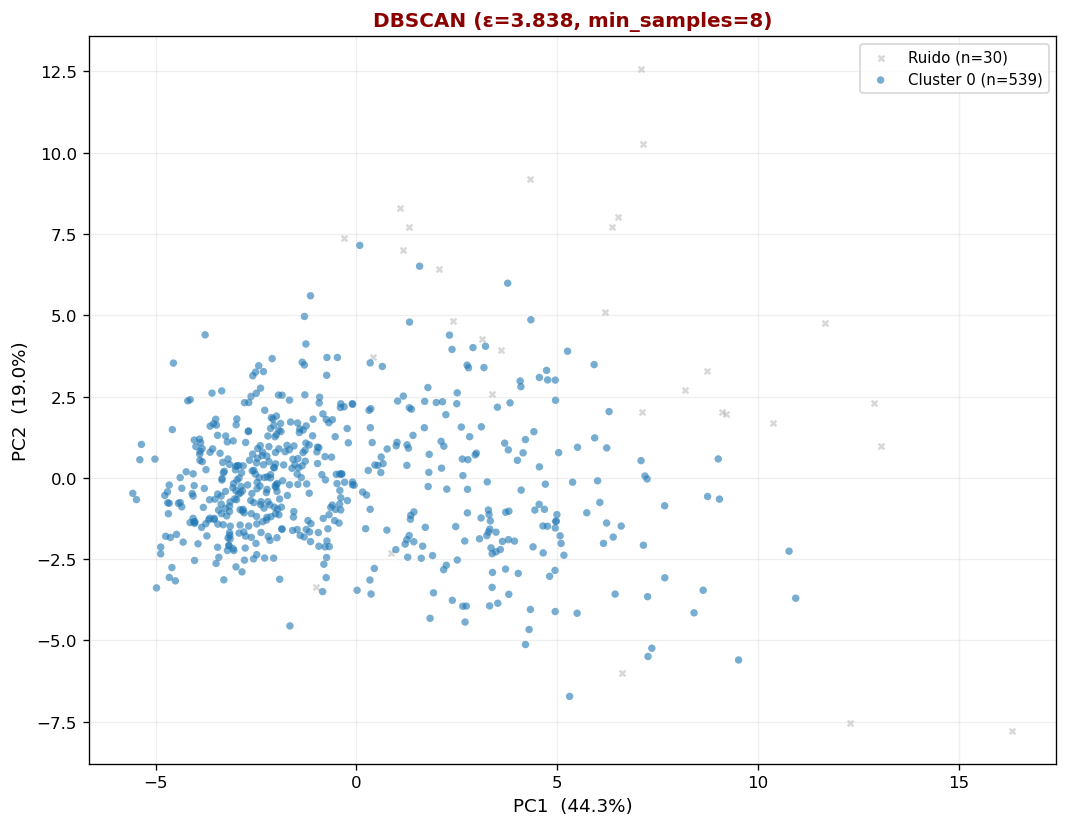

In [16]:
# ── DBSCAN: visualización en espacio PCA 2D ────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
unique_labels = sorted(set(labels_db))
colors_db  = cm.tab10(np.linspace(0, 0.9, max(n_clusters_db, 1)))
color_idx  = 0

for label in unique_labels:
    mask = labels_db == label
    if label == -1:
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   alpha=0.3, s=12, color='gray',
                   marker='x', label=f'Ruido (n={mask.sum()})')
    else:
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   alpha=0.6, s=20, color=colors_db[color_idx],
                   edgecolors='none', label=f'Cluster {label} (n={mask.sum()})')
        color_idx += 1

ax.set_xlabel(f'PC1  ({var_ratio[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2  ({var_ratio[1]:.1%})', fontsize=11)
ax.set_title(f'DBSCAN (ε={EPS:.3f}, min_samples={MIN_SAMPLES})',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('dbscan_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 5.4 — Interpretación

**📝 Tu respuesta (edita esta celda):**

**1. ¿Cuántos clusters encontró DBSCAN? ¿Coincide con la estructura visual del PCA 2D?**
DBSCAN encontró 1 cluster y 30 puntos de ruido. Se podría decir que corresponde regularmente, ya que si bien hay un agrupamiento claro en una nube principal, existe mucha dispersión al medio que no se consideró como ruido. Aún así se puede decir que sí encontró uno bien definido.

**2. ¿Qué representan clínicamente los puntos de ruido en este dataset?**
Los puntos de ruido representan valores atípicos, clinicamente se diría que son pacientes con tumores con características morfológicas muy distintas, ya que no se parecen al promedio. Esas muestras podrían representar pcasos con mediciones extremas, quizás errores o simplemente muestras difíciles de agrupar porque no pertenecen claramente a una región densa.

**3. ¿Cómo afecta cambiar ε al número de clusters y de puntos de ruido? Prueba al menos 2 valores distintos.**
Los valores hallados fueron estos:<br>
ε = 2.686853  -> n_clusters = 1 -> n_noise = 93<br>
ε = 3.838362  -> n_clusters = 1 -> n_noise = 30<br>
ε = 4.989871  -> n_clusters = 1 ->  n_noise = 12<br>
	
Como podemos observar, a medida que el ε aumenta, los puntos de ruido van disminuyendo. Esto se debe a que cuando aumentas el ε, indica que el radio de la vecindad se vuelve más grande, por ello puntos más alejados pueden ser incluidos dentro del cluster. <br>
En el caso de los clusters no cambia mucho, porque se identificó una sola región densa principal.

**4. A partir de la tabla de sensibilidad, ¿qué ocurre si `eps` es muy pequeño? ¿Y si `eps` es muy grande?**
Como dicho anteriormente, ε es el valor del radio de la vecindad. Si es muy pequeño, el modelo se vuelve muy conservador y puntos que podrían ser parte del cluster, pueden ser considerados ruido. En cambio, si ε se vuelve muy grande, el modelo se vuelve tan flexible que puntos lejanos se pueden considerar parte del cluster, introduciendo agrupamientos no confiables.


---
# PARTE 4 — Comparación Final
## Ejercicio 6 — Evaluación contra etiquetas reales

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 6.1 — Adjusted Rand Index y métricas comparativas

In [17]:
# ── Comparación con etiquetas reales ───────────────────────────
# ⚠️  PRIMERA VEZ que usamos y_true — revelamos las etiquetas reales solo al final
y_true = data.target

print(f'Clases reales: {data.target_names}  →  0=maligno, 1=benigno')
print(f'Distribución real: maligno={(y_true==0).sum()}, benigno={(y_true==1).sum()}')
print()

from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix as cm_func

def best_label_mapping(y_true, y_pred):
    cm = cm_func(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for col, row in zip(col_ind, row_ind)}
    return np.array([mapping.get(l, l) for l in y_pred])

labels_km_mapped = best_label_mapping(y_true, labels_km)

# TODO 16: calcula el ARI de K-means contra y_true
ari_km = adjusted_rand_score(y_true, labels_km)

# TODO 17a: calcula el ARI crudo de DBSCAN contra y_true
# Nota: DBSCAN etiqueta ruido como -1; matemáticamente puede incluirse en el ARI.
ari_db_raw = adjusted_rand_score(y_true, labels_db)

# TODO 17b: si DBSCAN tiene solo 1 cluster útil, reporta 0.0 como ARI clínico.
# Si tiene más de 1 cluster útil, usa ari_db_raw.
ari_db = ari_db_raw if n_clusters_db > 1 else 0.0

# TODO 18: calcula silhouette de K-means y de DBSCAN (sin ruido)
sil_km = silhouette_score(Z_pca, labels_km)
sil_db = silhouette_score(Z_pca[labels_db != -1], labels_db[labels_db != -1]) if n_clusters_db > 1 else 0.0

# TODO 19: calcula Davies-Bouldin de K-means y DBSCAN (sin ruido)
db_km  = davies_bouldin_score(Z_pca, labels_km)
db_db  = davies_bouldin_score(Z_pca[labels_db != -1], labels_db[labels_db != -1]) if n_clusters_db > 1 else float('nan')

print('=' * 86)
print('    COMPARACIÓN FINAL — K-means vs DBSCAN vs Etiquetas Reales')
print('=' * 86)
print(f'{"Método":<20} {"ARI clínico":^12} {"ARI crudo":^11} {"Silhouette":^12} {"Davies-Bouldin":^16} {"Clusters"}')
print('-' * 86)
print(f'{"K-means":<20} {ari_km:^12.4f} {ari_km:^11.4f} {sil_km:^12.4f} {db_km:^16.4f} {best_k}')
print(f'{"DBSCAN":<20} {ari_db:^12.4f} {ari_db_raw:^11.4f} {sil_db:^12.4f} {db_db:^16.4f} {n_clusters_db} (+{n_noise} ruido)')
print()
print('Interpretación: ARI→1=perfecto | Silhouette→+1=mejor | Davies-Bouldin→0=mejor')
if n_clusters_db <= 1:
    print('Nota DBSCAN: aunque el ARI crudo puede calcularse usando ruido=-1, se reporta ARI clínico=0.0 porque solo hay 1 cluster útil.')

Clases reales: ['malignant' 'benign']  →  0=maligno, 1=benigno
Distribución real: maligno=212, benigno=357

    COMPARACIÓN FINAL — K-means vs DBSCAN vs Etiquetas Reales
Método               ARI clínico   ARI crudo   Silhouette   Davies-Bouldin  Clusters
--------------------------------------------------------------------------------------
K-means                 0.6707      0.6707       0.3710         1.2159      2
DBSCAN                  0.0000      0.0335       0.0000          nan        1 (+30 ruido)

Interpretación: ARI→1=perfecto | Silhouette→+1=mejor | Davies-Bouldin→0=mejor
Nota DBSCAN: aunque el ARI crudo puede calcularse usando ruido=-1, se reporta ARI clínico=0.0 porque solo hay 1 cluster útil.


### Paso 6.2 — Visualización comparativa

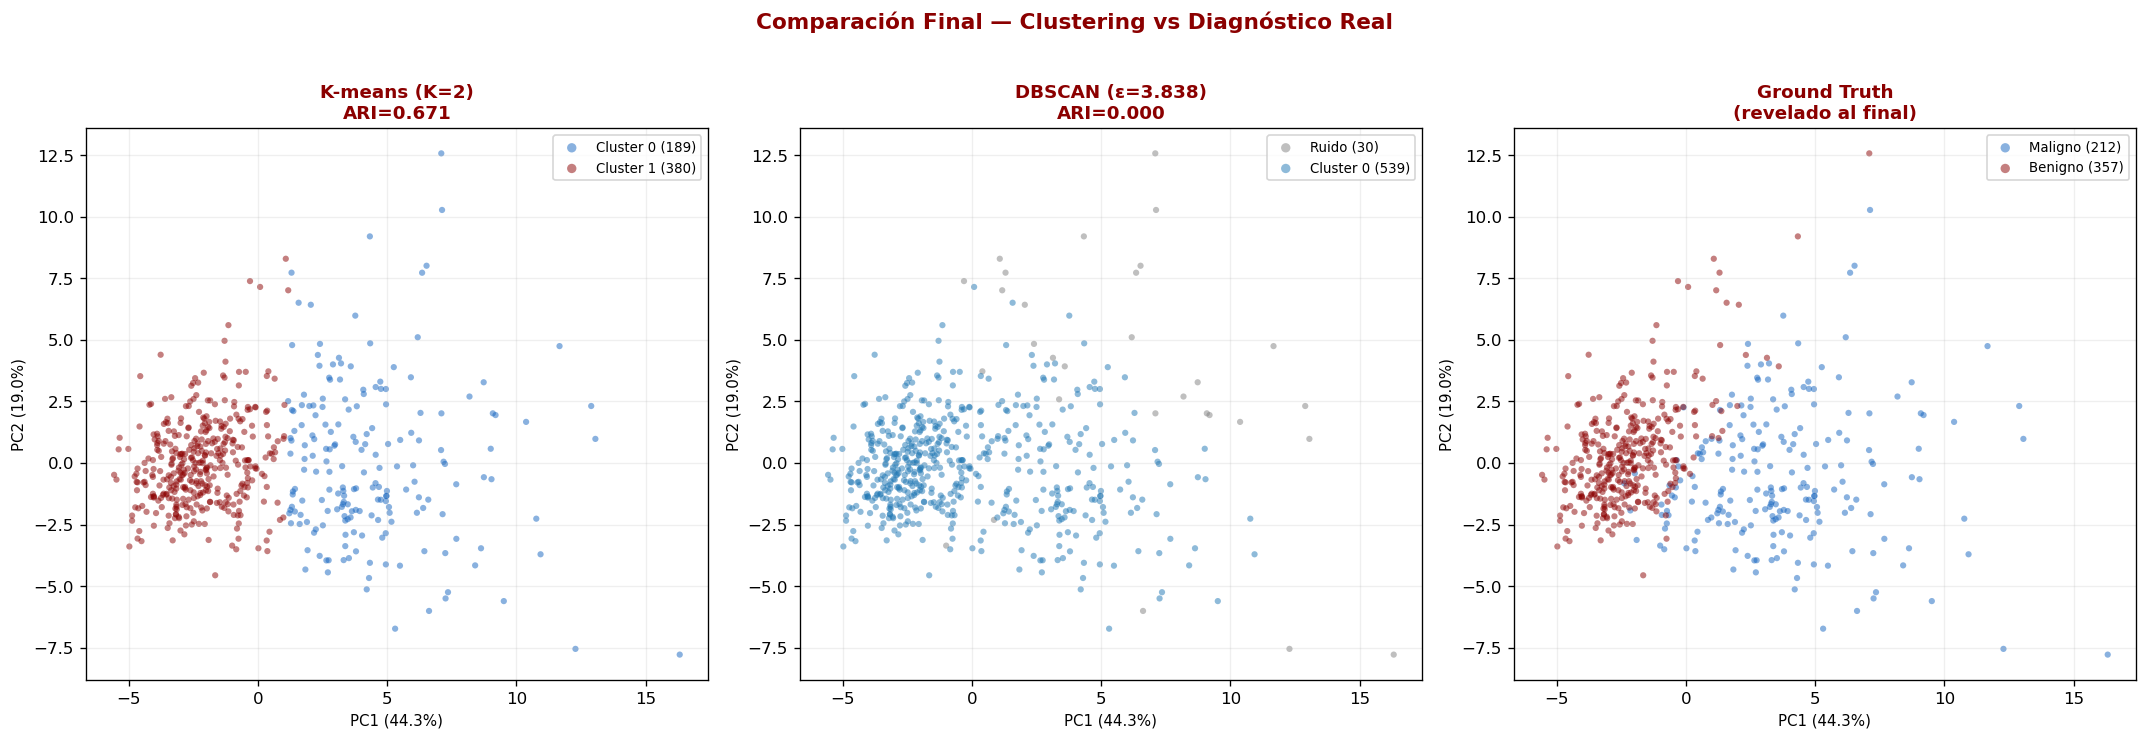

In [18]:
# ── Visualización comparativa: K-means vs DBSCAN vs Ground Truth
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
gt_labels = ['Maligno', 'Benigno']

# is_gt: flag explícito en lugar de 'labels is y_true' (antipatrón)
configs = [
    (labels_km_mapped, [UPCH_BLUE, UPCH_RED],
     f'K-means (K={best_k})\nARI={ari_km:.3f}', False),
    (labels_db, None,
     f'DBSCAN (ε={EPS:.3f})\nARI={ari_db:.3f}', False),
    (y_true, [UPCH_BLUE, UPCH_RED],
     'Ground Truth\n(revelado al final)', True),
]

for ax, (labels, cols, title, is_gt) in zip(axes, configs):
    unique = sorted(set(labels))
    if cols is None:
        palette = ['gray'] + list(cm.tab10(np.linspace(0, 0.7, max(len(unique)-1, 1))))
    else:
        palette = cols + ['gray']
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        lbl_name = ('Ruido' if lbl == -1 else
                    (gt_labels[lbl] if is_gt else f'Cluster {lbl}'))
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   alpha=0.5, s=14, color=palette[i % len(palette)],
                   edgecolors='none', label=f'{lbl_name} ({mask.sum()})')
    ax.set_title(title, fontsize=11, fontweight='bold', color=UPCH_RED)
    ax.set_xlabel(f'PC1 ({var_ratio[0]:.1%})', fontsize=9)
    ax.set_ylabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=9)
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.2)

plt.suptitle('Comparación Final — Clustering vs Diagnóstico Real',
             fontsize=13, fontweight='bold', color=UPCH_RED, y=1.02)
plt.tight_layout()
plt.savefig('comparacion_final.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 6.3 — Interpretación final

**📝 Tu respuesta (edita esta celda):**

**1. ¿Qué ARI obtuvo K-means? ¿Qué significa ese valor clínicamente?**
K-means obtuvo un ARI clínico de 0.6707, indicando que logró una buena separación clínica entre tumores malignos y benignos, tomando como referencia el Ground Truth. Clínicamente se puede interpretar como que el dataset si tiene la suficiente información útil para separar muestras de los dos casos.

**2. ¿K-means o DBSCAN recuperó mejor la distinción maligno/benigno? ¿Por qué?**
K-means fue mucho mejor, porque obtuvo un ARI clínico de 0.6707 a diferencia del 0 del DBSCAN. Además, como podemos ver en la comparación final, K-means sí encontró dos clusters, coincidiendo con el Ground Truth. Por su parte, el DBSCAN solo encontró un cluster y muestras de ruido.

**3. Tabla resumen — completa con los valores obtenidos:**

| Método | ARI clínico | ARI crudo | Silhouette | Davies-Bouldin | Nº clusters | Ruido |
|---|---:|---:|---:|---:|---:|---:|
| K-means | 0.6707 | 0.6707 | 0.3710 | 1.2159 | 2 | 0 |
| DBSCAN | 0.0000 | 0.0335 | 0.0000 | NaN | 1 | 30 |

**4. ¿Qué nos dice el ARI sobre el valor clínico de las 30 features morfológicas del FNA?**
El ARI demuestra que sí se tiene información de valor clínico en las 30 features del FNA, porque como se pudo ver, con el K-means se pudo recuperar parcialmente la separación de las muestras en dos grupos como en el Ground Truth. 

**5. ¿En qué escenario clínico sería útil el aprendizaje no supervisado si no se tuviera el diagnóstico histológico disponible?**
En el caso de clustering, no debería usarse como un diagnósitco definitivo, pero sí como un tamizaje inicial. Usarlo de esta manera permitiría generar agrupamientos iniciales según características morfológicas similares y también permitiría identificar aquellos valores que son atípicos, quizás para priorizar una revisión clínica más temprana o más detallada en esos casos.